1. Importar Biblioteca

In [ ]:
import pandas as pd

2. Base de Dados

In [ ]:
vinhos = pd.read_csv('/content/WineQT.csv')

3. Ver as primeiras linhas




In [ ]:
# Ver as primeiras 5 linhas do dataset
print("=== PRIMEIRAS LINHAS DO DATASET ===")
print(vinhos.head())

=== PRIMEIRAS LINHAS DO DATASET ===
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0 

4. Visualização Geral

In [ ]:
# Informações sobre as colunas e tipos de dados
print("\n=== INFORMAÇÕES DO DATASET ===")
print(vinhos.info())

# Dimensões do dataset
print(f"\nDimensões: {vinhos.shape[0]} linhas e {vinhos.shape[1]} colunas")



=== INFORMAÇÕES DO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None

Dimensões: 1143 linhas e 13 colunas


5. Estatística Descritiva

In [ ]:
# Resumo estatístico das variáveis
print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(vinhos.describe())



=== ESTATÍSTICAS DESCRITIVAS ===
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.01

6. Verificar Valores Faltantes

In [ ]:
# Verificar valores faltantes
print("=== VALORES FALTANTES ===")
print(vinhos.isnull().sum())
print(f"\nTotal de valores faltantes: {vinhos.isnull().sum().sum()}")


=== VALORES FALTANTES ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total de valores faltantes: 0


7. Analisar a Distribuição da Variável Alvo (Quality)

In [ ]:
# Contar quantos vinhos temos em cada nível de qualidade
print("\n=== DISTRIBUIÇÃO DA QUALIDADE ===")
print(vinhos['quality'].value_counts().sort_index())

# Percentual
print("\n=== PERCENTUAL POR QUALIDADE ===")
print(vinhos['quality'].value_counts(normalize=True).sort_index() * 100)



=== DISTRIBUIÇÃO DA QUALIDADE ===
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

=== PERCENTUAL POR QUALIDADE ===
quality
3     0.524934
4     2.887139
5    42.257218
6    40.419948
7    12.510936
8     1.399825
Name: proportion, dtype: float64


8. Variável Alvo Binária

=== DISTRIBUIÇÃO DA VARIÁVEL ALVO BINÁRIA ===
quality_binary
0    984
1    159
Name: count, dtype: int64

=== PERCENTUAL ===
quality_binary
0    86.089239
1    13.910761
Name: proportion, dtype: float64


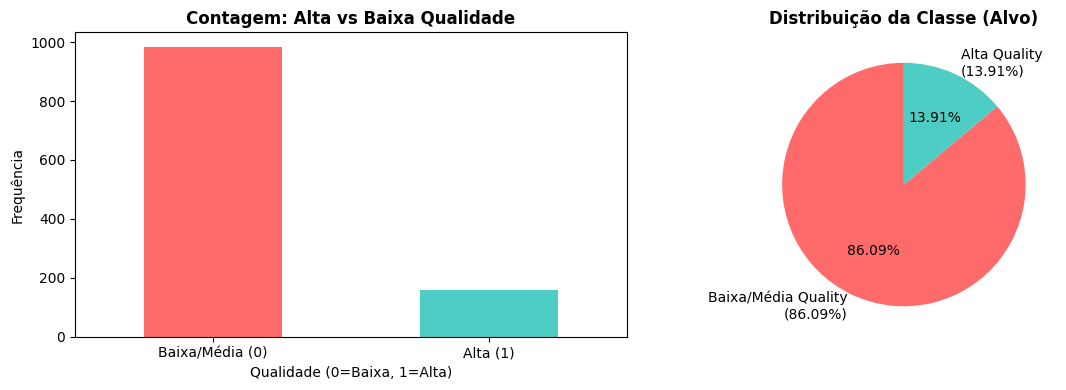


✅ Variável alvo binária criada com sucesso!


In [ ]:
# Criar variável alvo binária
# 1 = High Quality (score ≥ 7)
# 0 = Low/Medium Quality (score < 7)

vinhos['quality_binary'] = (vinhos['quality'] >= 7).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL ALVO BINÁRIA ===")
print(vinhos['quality_binary'].value_counts())
print("\n=== PERCENTUAL ===")
print(vinhos['quality_binary'].value_counts(normalize=True) * 100)

# Visualizar
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Contagem
vinhos['quality_binary'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Contagem: Alta vs Baixa Qualidade', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Qualidade (0=Baixa, 1=Alta)')
axes[0].set_ylabel('Frequência')
axes[0].set_xticklabels(['Baixa/Média (0)', 'Alta (1)'], rotation=0)

# Gráfico 2: Percentual (Pizza)
labels = ['Baixa/Média Quality\n(86.09%)', 'Alta Quality\n(13.91%)']
sizes = vinhos['quality_binary'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
axes[1].pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors, startangle=90)
axes[1].set_title('Distribuição da Classe (Alvo)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Variável alvo binária criada com sucesso!")


9. Relações entre features e o alvo


Correlação com Quality_Binary (≥ 7):
quality_binary          1.000000
quality                 0.720433
alcohol                 0.403676
citric acid             0.251146
sulphates               0.208020
fixed acidity           0.123212
residual sugar          0.064145
Id                      0.019165
free sulfur dioxide    -0.055977
pH                     -0.073318
chlorides              -0.103985
total sulfur dioxide   -0.113373
density                -0.148670
volatile acidity       -0.304523
Name: quality_binary, dtype: float64


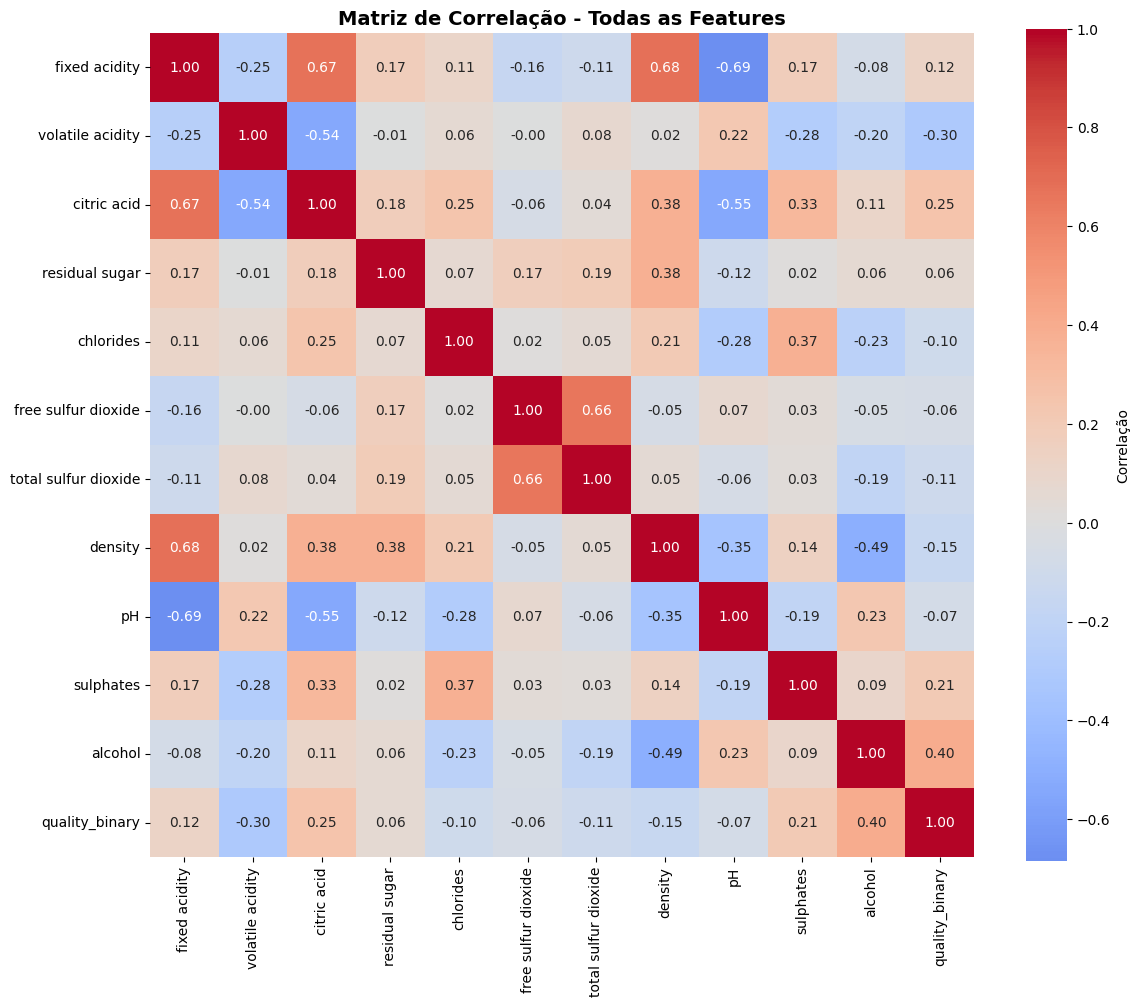

In [ ]:
import seaborn as sns
import numpy as np

# 1️⃣ MATRIZ DE CORRELAÇÃO

# Calcular correlações com a variável alvo
correlacoes = vinhos.corr()['quality_binary'].sort_values(ascending=False)
print("\nCorrelação com Quality_Binary (≥ 7):")
print(correlacoes)

# Visualizar matriz de correlação completa
plt.figure(figsize=(12, 10))
corr_matrix = vinhos.drop(['Id', 'quality'], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlação'}, square=True)
plt.title('Matriz de Correlação - Todas as Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


10. Analise Visual por Classe

/tmp/ipykernel_355/617695538.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vinhos, x='quality_binary', y=feature, ax=axes[idx],
/tmp/ipykernel_355/617695538.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vinhos, x='quality_binary', y=feature, ax=axes[idx],
/tmp/ipykernel_355/617695538.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vinhos, x='quality_binary', y=feature, ax=axes[idx],
/tmp/ipykernel_355/617695538.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remove

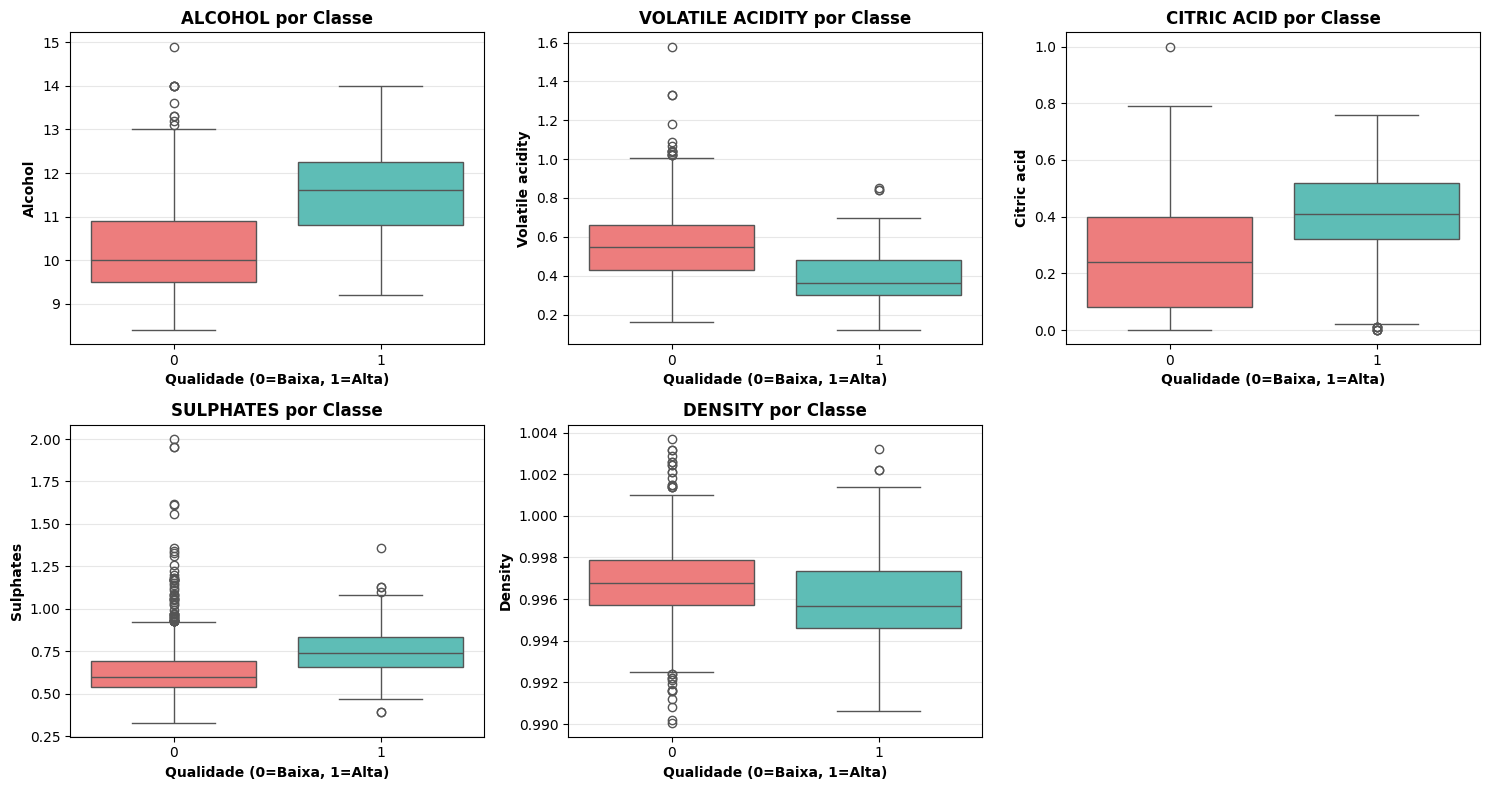

✅ Box plots das features mais importantes criados!


In [ ]:
# Distribuição das 5 features mais importantes
features_importantes = ['alcohol', 'volatile acidity', 'citric acid',
                       'sulphates', 'density']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(features_importantes):
    # Box plot
    sns.boxplot(data=vinhos, x='quality_binary', y=feature, ax=axes[idx],
                palette=['#FF6B6B', '#4ECDC4'])
    axes[idx].set_xlabel('Qualidade (0=Baixa, 1=Alta)', fontweight='bold')
    axes[idx].set_ylabel(feature.capitalize(), fontweight='bold')
    axes[idx].set_title(f'{feature.upper()} por Classe', fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

# Remover subplot extra
axes[-1].remove()

plt.tight_layout()
plt.show()

print("✅ Box plots das features mais importantes criados!")


11. Estatísticas Descritivas por Classe

In [ ]:
for feature in features_importantes:
    baixa = vinhos[vinhos['quality_binary'] == 0][feature]
    alta = vinhos[vinhos['quality_binary'] == 1][feature]

    print(f"\n🍷 {feature.upper()}")
    print(f"  Baixa Qualidade  → Média: {baixa.mean():.3f} | Desvio: {baixa.std():.3f}")
    print(f"  Alta Qualidade   → Média: {alta.mean():.3f} | Desvio: {alta.std():.3f}")
    print(f"  Diferença:         {(alta.mean() - baixa.mean()):.3f}")



🍷 ALCOHOL
  Baixa Qualidade  → Média: 10.267 | Desvio: 0.988
  Alta Qualidade   → Média: 11.528 | Desvio: 1.008
  Diferença:         1.262

🍷 VOLATILE ACIDITY
  Baixa Qualidade  → Média: 0.553 | Desvio: 0.176
  Alta Qualidade   → Média: 0.395 | Desvio: 0.135
  Diferença:         -0.158

🍷 CITRIC ACID
  Baixa Qualidade  → Média: 0.249 | Desvio: 0.190
  Alta Qualidade   → Média: 0.391 | Desvio: 0.195
  Diferença:         0.143

🍷 SULPHATES
  Baixa Qualidade  → Média: 0.643 | Desvio: 0.170
  Alta Qualidade   → Média: 0.746 | Desvio: 0.141
  Diferença:         0.102

🍷 DENSITY
  Baixa Qualidade  → Média: 0.997 | Desvio: 0.002
  Alta Qualidade   → Média: 0.996 | Desvio: 0.002
  Diferença:         -0.001


12. Pré Processamento dos Dados

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight


# 1️⃣ Separar features (X) e alvo (y)
X = vinhos.drop(['quality', 'quality_binary', 'Id'], axis=1)
y = vinhos['quality_binary']

print(f"\n✅ Features (X): {X.shape}")
print(f"✅ Alvo (y): {y.shape}")
print(f"\nFeatures utilizadas:\n{list(X.columns)}")

# 2️⃣ Dividir em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"\n" + "="*70)
print("DIVISÃO TREINO/TESTE (STRATIFICADA)")
print("="*70)
print(f"🔵 TREINO: {X_train.shape[0]} amostras")
print(f"   - Classe 0 (Baixa): {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"   - Classe 1 (Alta):  {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")

print(f"\n🔴 TESTE: {X_test.shape[0]} amostras")
print(f"   - Classe 0 (Baixa): {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"   - Classe 1 (Alta):  {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")

# 3️⃣ Normalizar features (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n" + "="*70)
print("NORMALIZAÇÃO (StandardScaler)")
print("="*70)
print(f"✅ Features normalizadas com média=0 e desvio=1")
print(f"✅ Escaler treinado apenas com dados de TREINO")

# 4️⃣ Calcular pesos para balancear classes
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\n" + "="*70)
print("PESOS PARA BALANCEAMENTO DE CLASSES")
print("="*70)
print(f"Classe 0 (Baixa):  peso = {class_weight_dict[0]:.3f}")
print(f"Classe 1 (Alta):   peso = {class_weight_dict[1]:.3f}")
print(f"→ Classe minoritária recebe maior peso para não ser ignorada!")

print(f"\n✅ DADOS PRONTOS PARA TREINAMENTO!")



✅ Features (X): (1143, 11)
✅ Alvo (y): (1143,)

Features utilizadas:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

DIVISÃO TREINO/TESTE (STRATIFICADA)
🔵 TREINO: 800 amostras
   - Classe 0 (Baixa): 689 (86.1%)
   - Classe 1 (Alta):  111 (13.9%)

🔴 TESTE: 343 amostras
   - Classe 0 (Baixa): 295 (86.0%)
   - Classe 1 (Alta):  48 (14.0%)

NORMALIZAÇÃO (StandardScaler)
✅ Features normalizadas com média=0 e desvio=1
✅ Escaler treinado apenas com dados de TREINO

PESOS PARA BALANCEAMENTO DE CLASSES
Classe 0 (Baixa):  peso = 0.581
Classe 1 (Alta):   peso = 3.604
→ Classe minoritária recebe maior peso para não ser ignorada!

✅ DADOS PRONTOS PARA TREINAMENTO!


13. Treinamento do Modelo

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

# ==================== MODELO 1: LOGISTIC REGRESSION ====================
print("\n🔵 MODELO 1: LOGISTIC REGRESSION (Baseline)")
print("-"*70)

lr_model = LogisticRegression(
    random_state=42,
    class_weight='balanced',  # Usa pesos automáticos
    max_iter=1000,
    solver='lbfgs'
)

lr_model.fit(X_train_scaled, y_train)
print("✅ Modelo treinado com sucesso!")

# Predições
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_test_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# ==================== MODELO 2: RANDOM FOREST ====================
print("\n🟢 MODELO 2: RANDOM FOREST (Ensemble)")
print("-"*70)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5
)

rf_model.fit(X_train_scaled, y_train)
print("✅ Modelo treinado com sucesso!")

# Predições
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)
y_test_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*70)
print("✅ AMBOS OS MODELOS TREINADOS!")
print("="*70)



🔵 MODELO 1: LOGISTIC REGRESSION (Baseline)
----------------------------------------------------------------------
✅ Modelo treinado com sucesso!

🟢 MODELO 2: RANDOM FOREST (Ensemble)
----------------------------------------------------------------------
✅ Modelo treinado com sucesso!

✅ AMBOS OS MODELOS TREINADOS!


14. Avaliação do Modelo

In [ ]:
# Função para exibir métricas
def avaliar_modelo(y_true, y_pred, y_pred_proba, nome_modelo, dataset="TESTE"):
    print(f"\n{'='*80}")
    print(f"📈 {nome_modelo} - DATASET {dataset}")
    print(f"{'='*80}")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)

    print(f"\n🎯 MÉTRICAS DE DESEMPENHO:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f} ({precision*100:.2f}%) - De cada predição positiva, quantas estão certas?")
    print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%) - De todos os positivos reais, quantos acertamos?")
    print(f"   F1-Score:  {f1:.4f} ({f1*100:.2f}%) - Balanço entre Precision e Recall")
    print(f"   ROC-AUC:   {auc:.4f} ({auc*100:.2f}%) - Discriminação entre classes")

    # Matriz de Confusão
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n📊 MATRIZ DE CONFUSÃO:")
    print(f"   Verdadeiros Negativos (TN):  {tn}")
    print(f"   Falsos Positivos (FP):       {fp}")
    print(f"   Falsos Negativos (FN):       {fn}")
    print(f"   Verdadeiros Positivos (TP):  {tp}")

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"\n   Specificity: {specificity:.4f} ({specificity*100:.2f}%) - Taxa de negativos corretos")

    return accuracy, precision, recall, f1, auc, cm

# ==================== AVALIAÇÃO LOGISTIC REGRESSION ====================
acc_lr_train, prec_lr_train, rec_lr_train, f1_lr_train, auc_lr_train, _ = avaliar_modelo(
    y_train, y_train_pred_lr, lr_model.predict_proba(X_train_scaled)[:, 1],
    "LOGISTIC REGRESSION", "TREINO"
)

acc_lr_test, prec_lr_test, rec_lr_test, f1_lr_test, auc_lr_test, cm_lr = avaliar_modelo(
    y_test, y_test_pred_lr, y_test_pred_proba_lr,
    "LOGISTIC REGRESSION", "TESTE"
)

# ==================== AVALIAÇÃO RANDOM FOREST ====================
acc_rf_train, prec_rf_train, rec_rf_train, f1_rf_train, auc_rf_train, _ = avaliar_modelo(
    y_train, y_train_pred_rf, rf_model.predict_proba(X_train_scaled)[:, 1],
    "RANDOM FOREST", "TREINO"
)

acc_rf_test, prec_rf_test, rec_rf_test, f1_rf_test, auc_rf_test, cm_rf = avaliar_modelo(
    y_test, y_test_pred_rf, y_test_pred_proba_rf,
    "RANDOM FOREST", "TESTE"
)

# ==================== COMPARAÇÃO FINAL ====================
print(f"\n\n{'='*80}")
print("🏆 COMPARAÇÃO FINAL (TESTE)")
print(f"{'='*80}")

resultados = {
    'Logistic Regression': {
        'Accuracy': acc_lr_test,
        'Precision': prec_lr_test,
        'Recall': rec_lr_test,
        'F1-Score': f1_lr_test,
        'ROC-AUC': auc_lr_test
    },
    'Random Forest': {
        'Accuracy': acc_rf_test,
        'Precision': prec_rf_test,
        'Recall': rec_rf_test,
        'F1-Score': f1_rf_test,
        'ROC-AUC': auc_rf_test
    }
}

df_resultados = pd.DataFrame(resultados).T
print("\n" + df_resultados.to_string())

print(f"\n\n{'='*80}")
print("⚠️ OVERFITTING CHECK (diferença Treino - Teste)")
print(f"{'='*80}")
print(f"\nLogistic Regression:")
print(f"   Accuracy:  {(acc_lr_train - acc_lr_test):.4f}")
print(f"   F1-Score:  {(f1_lr_train - f1_lr_test):.4f}")

print(f"\nRandom Forest:")
print(f"   Accuracy:  {(acc_rf_train - acc_rf_test):.4f}")
print(f"   F1-Score:  {(f1_rf_train - f1_rf_test):.4f}")



📈 LOGISTIC REGRESSION - DATASET TREINO

🎯 MÉTRICAS DE DESEMPENHO:
   Accuracy:  0.8213 (82.12%)
   Precision: 0.4279 (42.79%) - De cada predição positiva, quantas estão certas?
   Recall:    0.8559 (85.59%) - De todos os positivos reais, quantos acertamos?
   F1-Score:  0.5706 (57.06%) - Balanço entre Precision e Recall
   ROC-AUC:   0.9128 (91.28%) - Discriminação entre classes

📊 MATRIZ DE CONFUSÃO:
   Verdadeiros Negativos (TN):  562
   Falsos Positivos (FP):       127
   Falsos Negativos (FN):       16
   Verdadeiros Positivos (TP):  95

   Specificity: 0.8157 (81.57%) - Taxa de negativos corretos

📈 LOGISTIC REGRESSION - DATASET TESTE

🎯 MÉTRICAS DE DESEMPENHO:
   Accuracy:  0.7697 (76.97%)
   Precision: 0.3368 (33.68%) - De cada predição positiva, quantas estão certas?
   Recall:    0.6667 (66.67%) - De todos os positivos reais, quantos acertamos?
   F1-Score:  0.4476 (44.76%) - Balanço entre Precision e Recall
   ROC-AUC:   0.8158 (81.58%) - Discriminação entre classes

📊 MATRI

15. Analise dos Resultados

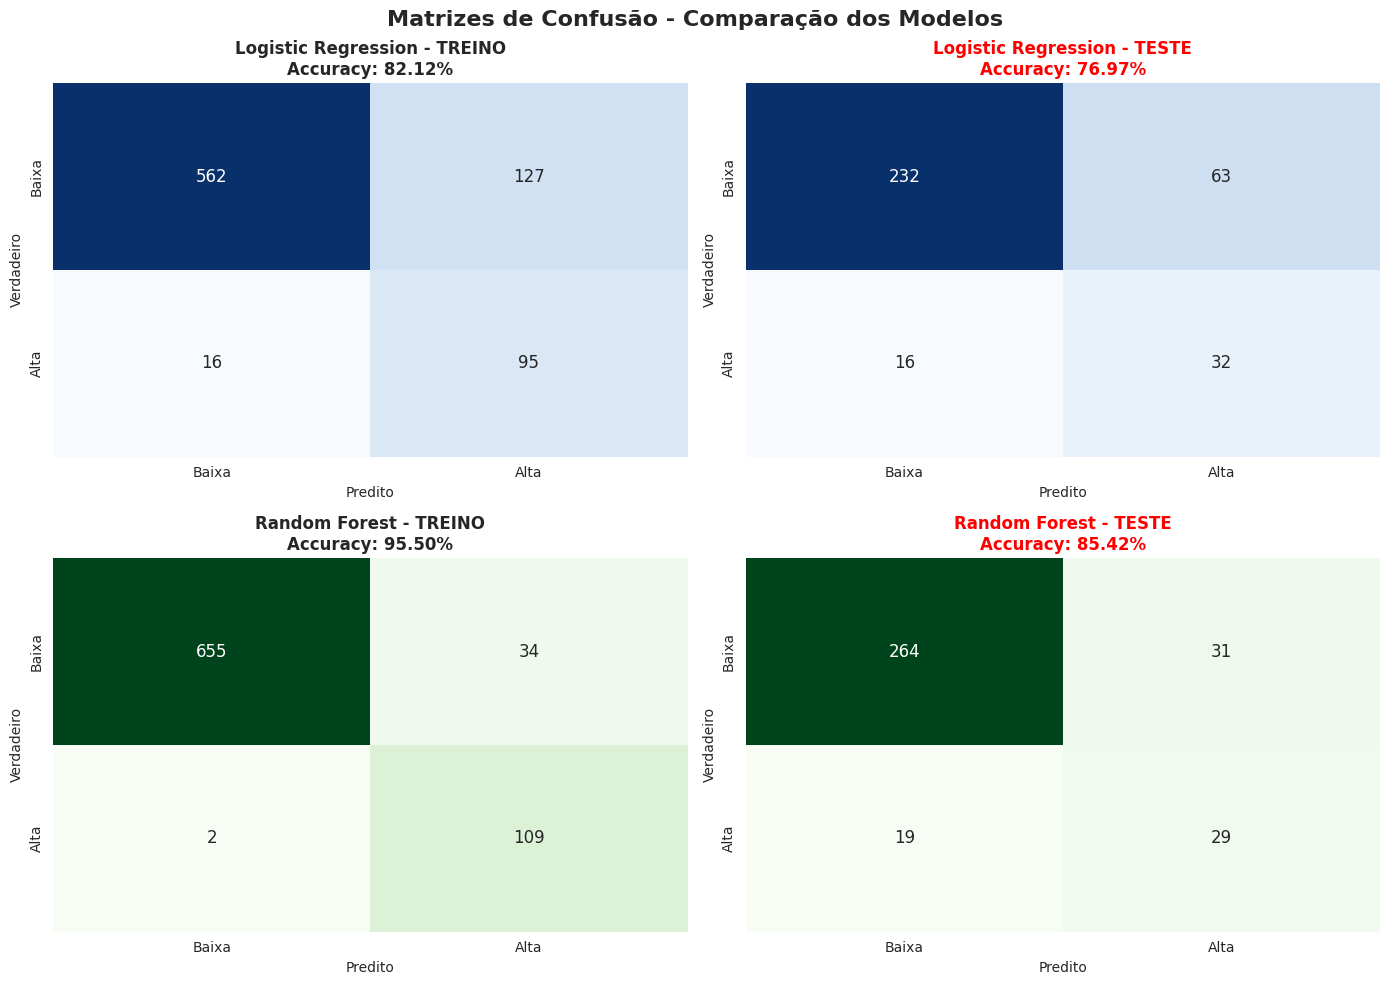

✅ Matrizes de Confusão salvas em: 01_confusion_matrices.png


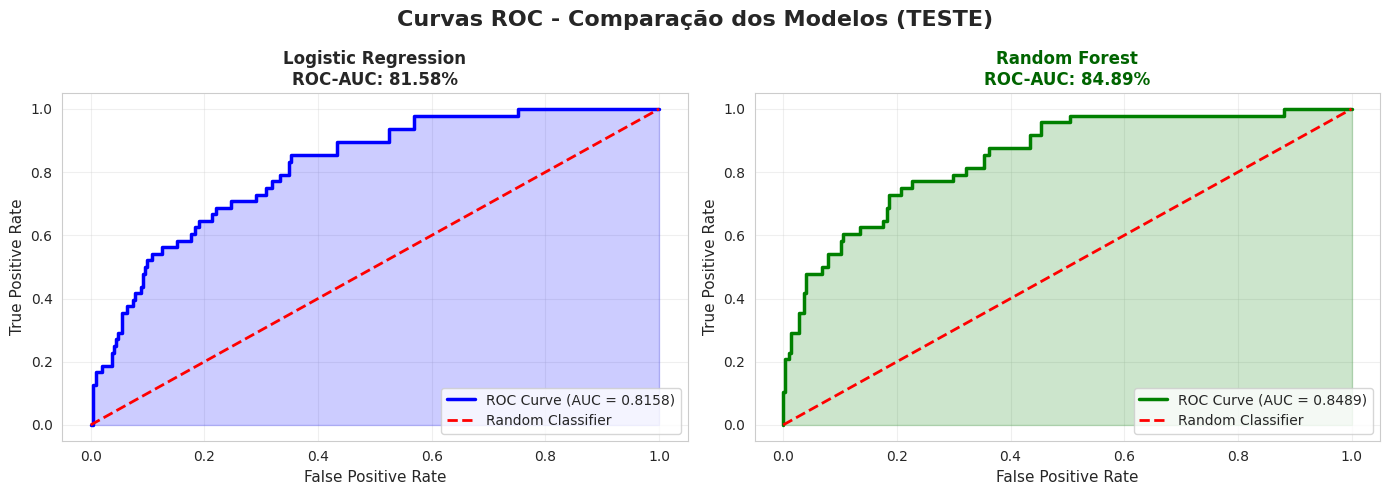

✅ Curvas ROC salvas em: 02_roc_curves.png


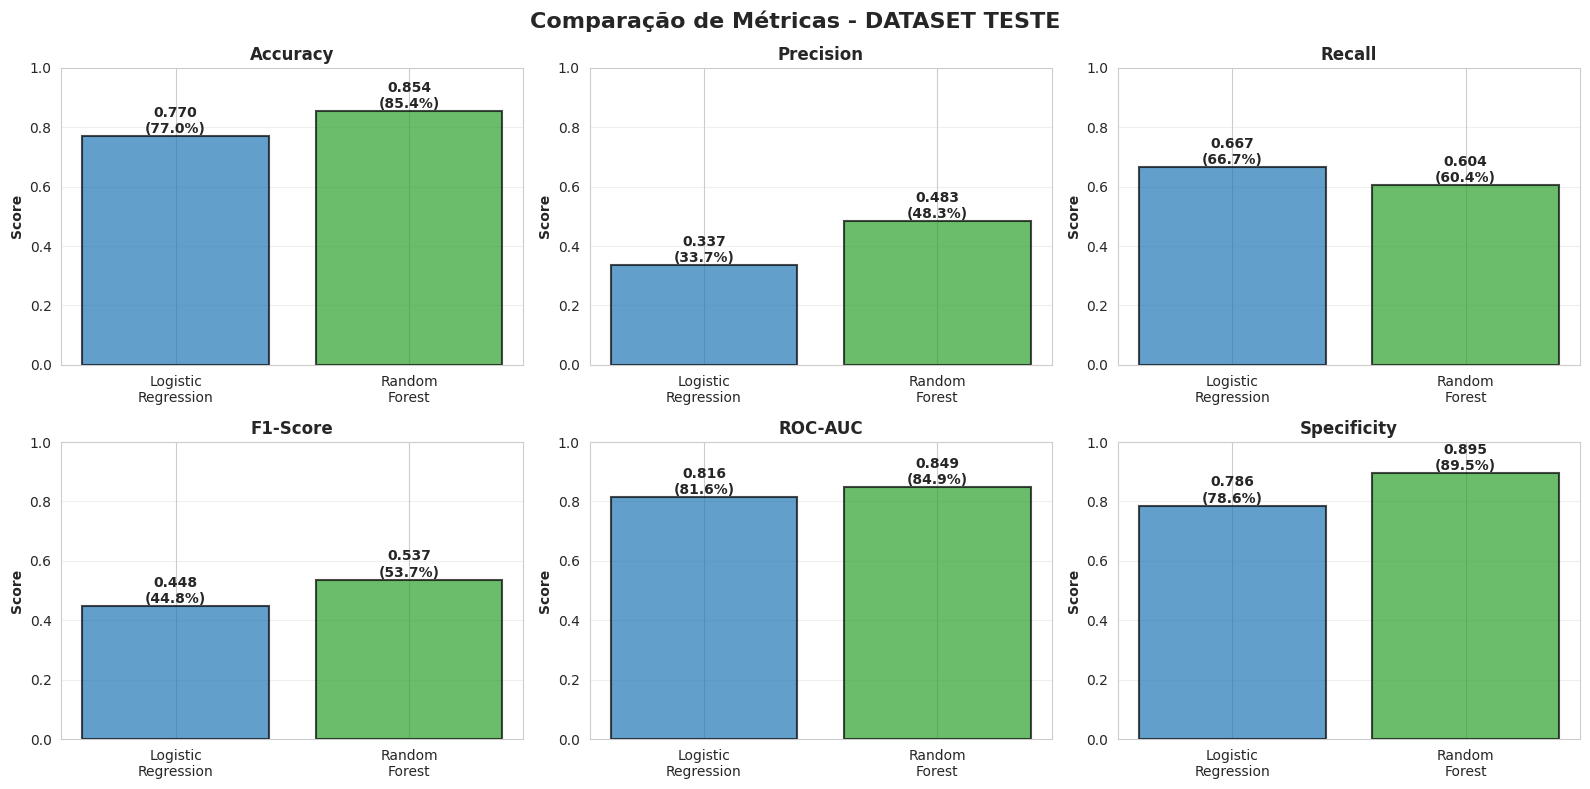

✅ Comparação de Métricas salva em: 03_metricas_comparison.png


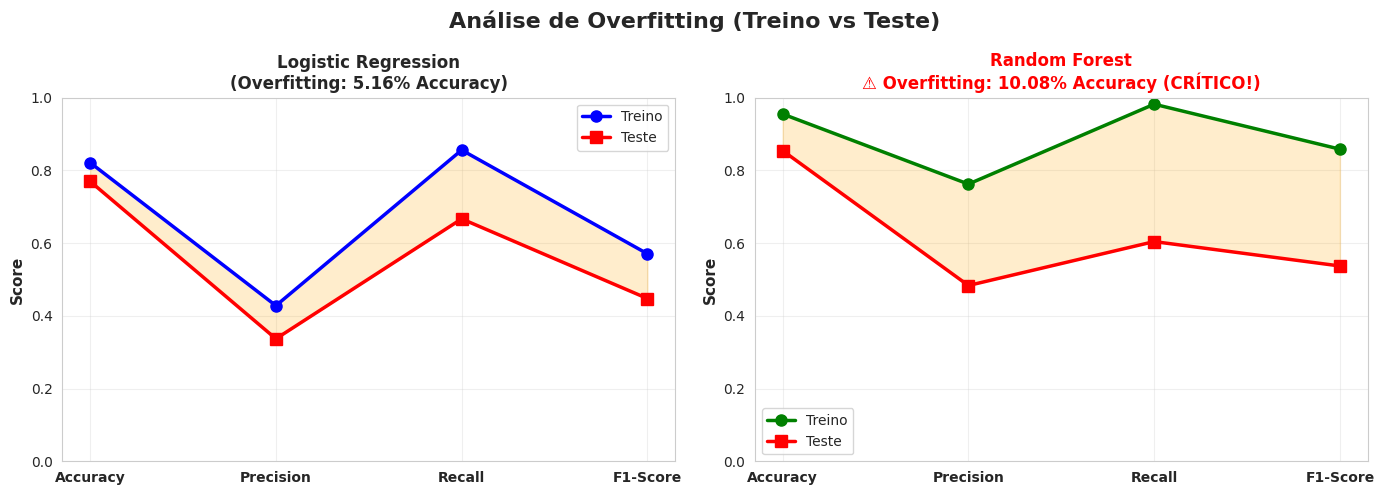

✅ Análise de Overfitting salva em: 04_overfitting_analysis.png

✅ TODAS AS VISUALIZAÇÕES CRIADAS COM SUCESSO!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# ==================== FIGURA 1: MATRIZES DE CONFUSÃO ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Matrizes de Confusão - Comparação dos Modelos', fontsize=16, fontweight='bold')

# Logistic Regression - Treino
cm_lr_train = confusion_matrix(y_train, y_train_pred_lr)
sns.heatmap(cm_lr_train, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            cbar=False, annot_kws={'size': 12})
axes[0, 0].set_title('Logistic Regression - TREINO\nAccuracy: 82.12%', fontweight='bold')
axes[0, 0].set_ylabel('Verdadeiro')
axes[0, 0].set_xlabel('Predito')
axes[0, 0].set_xticklabels(['Baixa', 'Alta'])
axes[0, 0].set_yticklabels(['Baixa', 'Alta'])

# Logistic Regression - Teste
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            cbar=False, annot_kws={'size': 12})
axes[0, 1].set_title('Logistic Regression - TESTE\nAccuracy: 76.97%', fontweight='bold', color='red')
axes[0, 1].set_ylabel('Verdadeiro')
axes[0, 1].set_xlabel('Predito')
axes[0, 1].set_xticklabels(['Baixa', 'Alta'])
axes[0, 1].set_yticklabels(['Baixa', 'Alta'])

# Random Forest - Treino
cm_rf_train = confusion_matrix(y_train, y_train_pred_rf)
sns.heatmap(cm_rf_train, annot=True, fmt='d', cmap='Greens', ax=axes[1, 0],
            cbar=False, annot_kws={'size': 12})
axes[1, 0].set_title('Random Forest - TREINO\nAccuracy: 95.50%', fontweight='bold')
axes[1, 0].set_ylabel('Verdadeiro')
axes[1, 0].set_xlabel('Predito')
axes[1, 0].set_xticklabels(['Baixa', 'Alta'])
axes[1, 0].set_yticklabels(['Baixa', 'Alta'])

# Random Forest - Teste
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            cbar=False, annot_kws={'size': 12})
axes[1, 1].set_title('Random Forest - TESTE\nAccuracy: 85.42%', fontweight='bold', color='red')
axes[1, 1].set_ylabel('Verdadeiro')
axes[1, 1].set_xlabel('Predito')
axes[1, 1].set_xticklabels(['Baixa', 'Alta'])
axes[1, 1].set_yticklabels(['Baixa', 'Alta'])

plt.tight_layout()
plt.savefig('01_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Matrizes de Confusão salvas em: 01_confusion_matrices.png")

# ==================== FIGURA 2: CURVA ROC ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas ROC - Comparação dos Modelos (TESTE)', fontsize=16, fontweight='bold')

# ROC Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

axes[0].plot(fpr_lr, tpr_lr, color='blue', lw=2.5, label=f'ROC Curve (AUC = {roc_auc_lr:.4f})')
axes[0].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[0].fill_between(fpr_lr, tpr_lr, alpha=0.2, color='blue')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Logistic Regression\nROC-AUC: 81.58%', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# ROC Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[1].plot(fpr_rf, tpr_rf, color='green', lw=2.5, label=f'ROC Curve (AUC = {roc_auc_rf:.4f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr_rf, tpr_rf, alpha=0.2, color='green')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('Random Forest\nROC-AUC: 84.89%', fontweight='bold', color='darkgreen')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Curvas ROC salvas em: 02_roc_curves.png")

# ==================== FIGURA 3: COMPARAÇÃO DE MÉTRICAS ====================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Comparação de Métricas - DATASET TESTE', fontsize=16, fontweight='bold')

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Specificity']
lr_values = [acc_lr_test, prec_lr_test, rec_lr_test, f1_lr_test, auc_lr_test,
             232/(232+63)]  # Specificity
rf_values = [acc_rf_test, prec_rf_test, rec_rf_test, f1_rf_test, auc_rf_test,
             264/(264+31)]  # Specificity

colors_lr = ['#1f77b4'] * 6
colors_rf = ['#2ca02c'] * 6

for idx, (ax, metrica, lr_val, rf_val) in enumerate(zip(axes.flat, metricas, lr_values, rf_values)):
    x = ['Logistic\nRegression', 'Random\nForest']
    values = [lr_val, rf_val]
    colors = ['#1f77b4', '#2ca02c']

    bars = ax.bar(x, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

    # Adicionar valores nas barras
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}\n({val*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

    ax.set_ylim(0, 1)
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(f'{metrica}', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_metricas_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Comparação de Métricas salva em: 03_metricas_comparison.png")

# ==================== FIGURA 4: OVERFITTING ANALYSIS ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análise de Overfitting (Treino vs Teste)', fontsize=16, fontweight='bold')

# Logistic Regression
lr_train_vals = [acc_lr_train, prec_lr_train, rec_lr_train, f1_lr_train]
lr_test_vals = [acc_lr_test, prec_lr_test, rec_lr_test, f1_lr_test]
x_pos = range(4)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

axes[0].plot(x_pos, lr_train_vals, marker='o', linewidth=2.5, markersize=8,
             label='Treino', color='blue')
axes[0].plot(x_pos, lr_test_vals, marker='s', linewidth=2.5, markersize=8,
             label='Teste', color='red')
axes[0].fill_between(x_pos, lr_train_vals, lr_test_vals, alpha=0.2, color='orange')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(metrics_names, fontweight='bold')
axes[0].set_ylabel('Score', fontweight='bold', fontsize=11)
axes[0].set_title('Logistic Regression\n(Overfitting: 5.16% Accuracy)', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Random Forest
rf_train_vals = [acc_rf_train, prec_rf_train, rec_rf_train, f1_rf_train]
rf_test_vals = [acc_rf_test, prec_rf_test, rec_rf_test, f1_rf_test]

axes[1].plot(x_pos, rf_train_vals, marker='o', linewidth=2.5, markersize=8,
             label='Treino', color='green')
axes[1].plot(x_pos, rf_test_vals, marker='s', linewidth=2.5, markersize=8,
             label='Teste', color='red')
axes[1].fill_between(x_pos, rf_train_vals, rf_test_vals, alpha=0.2, color='orange')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(metrics_names, fontweight='bold')
axes[1].set_ylabel('Score', fontweight='bold', fontsize=11)
axes[1].set_title('Random Forest\n⚠️ Overfitting: 10.08% Accuracy (CRÍTICO!)',
                  fontweight='bold', color='red')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Análise de Overfitting salva em: 04_overfitting_analysis.png")

print("\n" + "="*80)
print("✅ TODAS AS VISUALIZAÇÕES CRIADAS COM SUCESSO!")
print("="*80)


16. Análise de Importância das Features


🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳
📊 RANDOM FOREST - FEATURE IMPORTANCE
🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳
             Feature  Importance
             alcohol    0.247933
         citric acid    0.156483
    volatile acidity    0.140062
           sulphates    0.132174
             density    0.068413
total sulfur dioxide    0.061505
       fixed acidity    0.052970
                  pH    0.042819
           chlorides    0.041260
      residual sugar    0.030400
 free sulfur dioxide    0.025980

📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈
📊 LOGISTIC REGRESSION - COEFICIENTES (Valor Absoluto)
📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈
             Feature  Coefficient
             alcohol     1.006165
           sulphates     0.714198
    volatile acidity     0.677058
         citric acid     0.526012
total sulfur dioxide     0.478155
           chlorides     0.418380
      residual sugar     0.390267
             density     0.353462
                  pH     0.282372
       

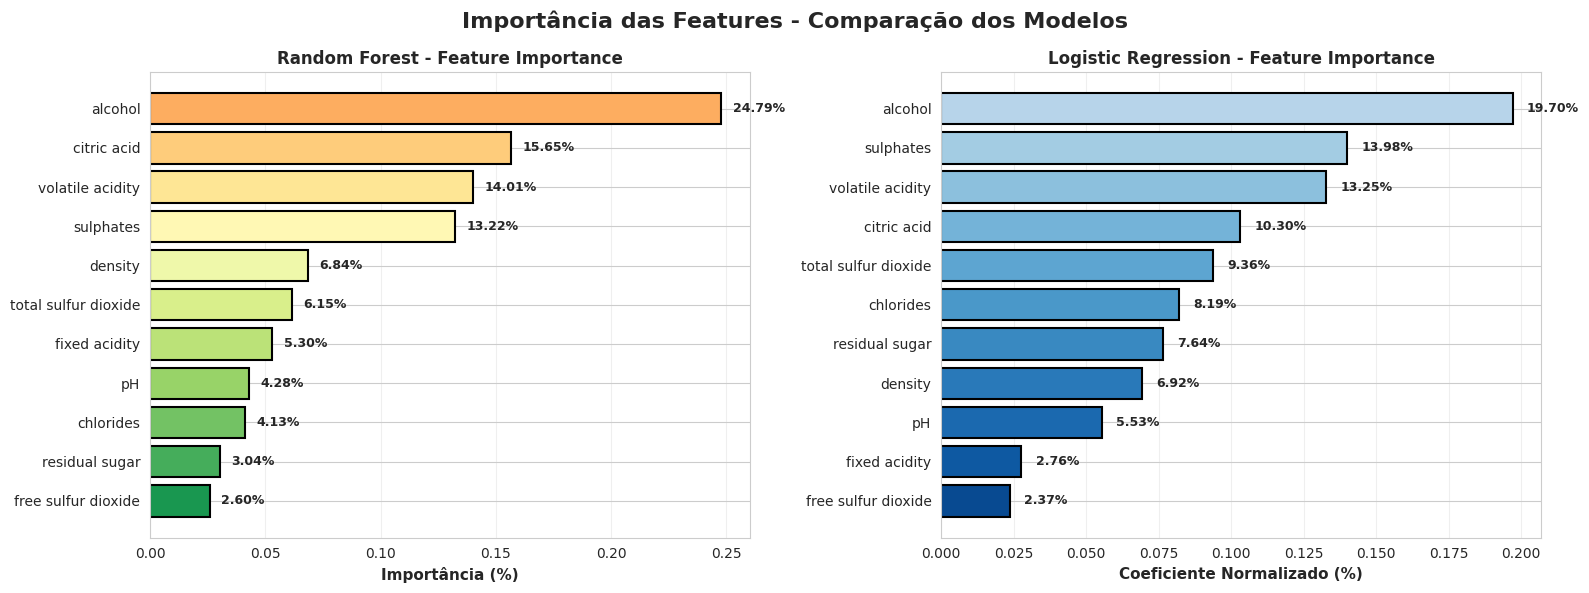


✅ Gráfico de Feature Importance salvo em: 05_feature_importance_comparison.png

🔎 ANÁLISE DETALHADA DA IMPORTÂNCIA DAS FEATURES

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
TOP 5 FEATURES MAIS IMPORTANTES (Random Forest)
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

1️⃣  ALCOHOL
   └─ Importância: 24.79%

2️⃣  CITRIC ACID
   └─ Importância: 15.65%

3️⃣  VOLATILE ACIDITY
   └─ Importância: 14.01%

4️⃣  SULPHATES
   └─ Importância: 13.22%

5️⃣  DENSITY
   └─ Importância: 6.84%

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
TOP 5 FEATURES MAIS IMPORTANTES (Logistic Regression)
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

1️⃣  ALCOHOL
   └─ Coeficiente: 1.0062

2️⃣  SULPHATES
   └─ Coeficiente: 0.7142

3️⃣  VOLATILE ACIDITY
   └─ Coeficiente: 0.6771

4️⃣  CITRIC ACID
   └─ Coeficiente: 0.5260

5️⃣  TOTAL SULFUR DIOXIDE
   └─ Coeficiente: 0.4782


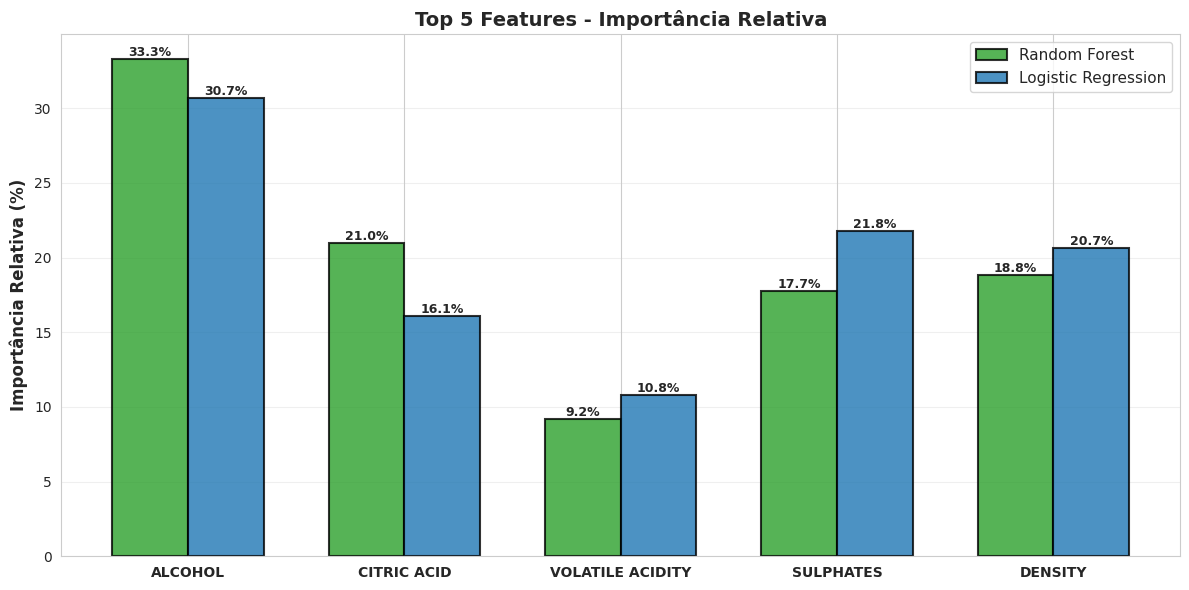


✅ Gráfico Top 5 Features salvo em: 06_top5_features_comparison.png

🔄 PERMUTATION IMPORTANCE (Validação de Importância)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



📊 PERMUTATION IMPORTANCE (Random Forest - Dataset Teste)
             Feature  Importance  Std
       fixed acidity         0.0  0.0
    volatile acidity         0.0  0.0
         citric acid         0.0  0.0
      residual sugar         0.0  0.0
           chlorides         0.0  0.0
 free sulfur dioxide         0.0  0.0
total sulfur dioxide         0.0  0.0
             density         0.0  0.0
                  pH         0.0  0.0
           sulphates         0.0  0.0
             alcohol         0.0  0.0


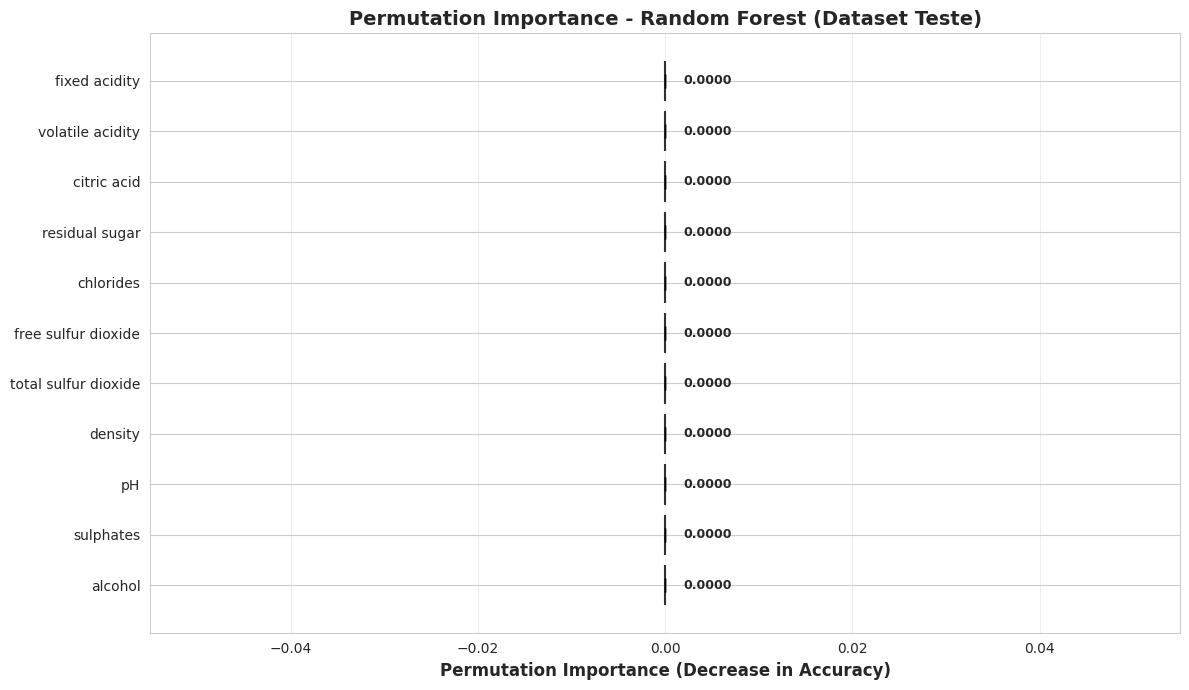


✅ Gráfico Permutation Importance salvo em: 07_permutation_importance.png

📋 RESUMO EXECUTIVO - IMPORTÂNCIA DAS FEATURES

---------------------------🥇 FEATURES MAIS INFLUENTES---------------------------

Random Forest (Top 3):
1. ALCOHOL: 24.79%
2. CITRIC ACID: 15.65%
3. VOLATILE ACIDITY: 14.01%

Logistic Regression (Top 3):
1. ALCOHOL: 1.0062
2. SULPHATES: 0.7142
3. VOLATILE ACIDITY: 0.6771

--------------------------------🔍 INTERPRETAÇÃO---------------------------------

✓ Ambos modelos concordam que ÁLCOOL é a feature mais importante
✓ Ácido volátil também tem alta importância em ambos
✓ Sulfatos aparecem entre as top 3 em ambos modelos
✓ Isso valida a importância destas features biologicamente

-----------------------⚠️ FEATURES COM BAIXA IMPORTÂNCIA------------------------

Random Forest (Bottom 3):
9. RESIDUAL SUGAR: 3.04%
10. FREE SULFUR DIOXIDE: 2.60%

→ Estas features contribuem pouco para a predição
→ Poderiam ser removidas sem grande perda de performance



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== EXTRAIR FEATURE IMPORTANCE ====================
# Random Forest Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "🌳"*40)
print("📊 RANDOM FOREST - FEATURE IMPORTANCE")
print("🌳"*40)
print(feature_importance_rf.to_string(index=False))

# Logistic Regression Coefficients
feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=False)

print("\n" + "📈"*40)
print("📊 LOGISTIC REGRESSION - COEFICIENTES (Valor Absoluto)")
print("📈"*40)
print(feature_importance_lr.to_string(index=False))

# ==================== FIGURA 5: FEATURE IMPORTANCE COMPARISON ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Importância das Features - Comparação dos Modelos', fontsize=16, fontweight='bold')

# Random Forest
colors_rf = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_importance_rf)))
axes[0].barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'],
             color=colors_rf, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Importância (%)', fontweight='bold', fontsize=11)
axes[0].set_title('Random Forest - Feature Importance', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Adicionar valores
for i, v in enumerate(feature_importance_rf['Importance']):
    axes[0].text(v + 0.005, i, f'{v*100:.2f}%', va='center', fontweight='bold', fontsize=9)

# Logistic Regression
# Normalizar coeficientes para percentual
coef_norm = feature_importance_lr['Coefficient'] / feature_importance_lr['Coefficient'].sum()
colors_lr = plt.cm.Blues(np.linspace(0.3, 0.9, len(feature_importance_lr)))
axes[1].barh(feature_importance_lr['Feature'], coef_norm,
             color=colors_lr, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Coeficiente Normalizado (%)', fontweight='bold', fontsize=11)
axes[1].set_title('Logistic Regression - Feature Importance', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Adicionar valores
for i, v in enumerate(coef_norm):
    axes[1].text(v + 0.005, i, f'{v*100:.2f}%', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('05_feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Gráfico de Feature Importance salvo em: 05_feature_importance_comparison.png")

# ==================== ANÁLISE DETALHADA ====================
print("\n" + "="*80)
print("🔎 ANÁLISE DETALHADA DA IMPORTÂNCIA DAS FEATURES")
print("="*80)

print("\n" + "🏆"*40)
print("TOP 5 FEATURES MAIS IMPORTANTES (Random Forest)")
print("🏆"*40)

top_5_rf = feature_importance_rf.head(5).reset_index(drop=True)
for idx, row in top_5_rf.iterrows():
    print(f"\n{idx+1}️⃣  {row['Feature'].upper()}")
    print(f"   └─ Importância: {row['Importance']*100:.2f}%")

print("\n" + "🏆"*40)
print("TOP 5 FEATURES MAIS IMPORTANTES (Logistic Regression)")
print("🏆"*40)

top_5_lr = feature_importance_lr.head(5).reset_index(drop=True)
for idx, row in top_5_lr.iterrows():
    print(f"\n{idx+1}️⃣  {row['Feature'].upper()}")
    print(f"   └─ Coeficiente: {row['Coefficient']:.4f}")

# ==================== FIGURA 6: TOP 5 FEATURES STACKED ====================
fig, ax = plt.subplots(figsize=(12, 6))

top_n = 5
features_top = feature_importance_rf.head(top_n)['Feature'].tolist()

# Preparar dados
rf_top_values = feature_importance_rf[feature_importance_rf['Feature'].isin(features_top)].sort_values('Feature')
lr_top_values = feature_importance_lr[feature_importance_lr['Feature'].isin(features_top)].sort_values('Feature')

# Normalizar para comparação
rf_norm = (rf_top_values['Importance'].values / rf_top_values['Importance'].sum()) * 100
lr_norm = (lr_top_values['Coefficient'].values / lr_top_values['Coefficient'].sum()) * 100

x = np.arange(len(features_top))
width = 0.35

bars1 = ax.bar(x - width/2, rf_norm, width, label='Random Forest',
               color='#2ca02c', edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x + width/2, lr_norm, width, label='Logistic Regression',
               color='#1f77b4', edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_ylabel('Importância Relativa (%)', fontweight='bold', fontsize=12)
ax.set_title('Top 5 Features - Importância Relativa', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f.upper() for f in features_top], fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('06_top5_features_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Gráfico Top 5 Features salvo em: 06_top5_features_comparison.png")

# ==================== PERMUTATION IMPORTANCE (Random Forest) ====================
print("\n" + "="*80)
print("🔄 PERMUTATION IMPORTANCE (Validação de Importância)")
print("="*80)

from sklearn.inspection import permutation_importance

# Calcular permutation importance no dataset de teste
perm_importance = permutation_importance(rf_model, X_test, y_test,
                                         n_repeats=10, random_state=42, n_jobs=-1)

perm_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\n📊 PERMUTATION IMPORTANCE (Random Forest - Dataset Teste)")
print(perm_importance_df.to_string(index=False))

# ==================== FIGURA 7: PERMUTATION IMPORTANCE ====================
fig, ax = plt.subplots(figsize=(12, 7))

colors_perm = plt.cm.viridis(np.linspace(0.3, 0.9, len(perm_importance_df)))
bars = ax.barh(perm_importance_df['Feature'], perm_importance_df['Importance'],
               xerr=perm_importance_df['Std'], color=colors_perm,
               edgecolor='black', linewidth=1.5, alpha=0.8, capsize=5)

ax.set_xlabel('Permutation Importance (Decrease in Accuracy)', fontweight='bold', fontsize=12)
ax.set_title('Permutation Importance - Random Forest (Dataset Teste)',
             fontweight='bold', fontsize=14)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Adicionar valores
for i, v in enumerate(perm_importance_df['Importance']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('07_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Gráfico Permutation Importance salvo em: 07_permutation_importance.png")

# ==================== RESUMO EXECUTIVO ====================
print("\n" + "="*80)
print("📋 RESUMO EXECUTIVO - IMPORTÂNCIA DAS FEATURES")
print("="*80)

print(f"""
{'🥇 FEATURES MAIS INFLUENTES':-^80}

Random Forest (Top 3):
1. {feature_importance_rf.iloc[0]['Feature'].upper()}: {feature_importance_rf.iloc[0]['Importance']*100:.2f}%
2. {feature_importance_rf.iloc[1]['Feature'].upper()}: {feature_importance_rf.iloc[1]['Importance']*100:.2f}%
3. {feature_importance_rf.iloc[2]['Feature'].upper()}: {feature_importance_rf.iloc[2]['Importance']*100:.2f}%

Logistic Regression (Top 3):
1. {feature_importance_lr.iloc[0]['Feature'].upper()}: {feature_importance_lr.iloc[0]['Coefficient']:.4f}
2. {feature_importance_lr.iloc[1]['Feature'].upper()}: {feature_importance_lr.iloc[1]['Coefficient']:.4f}
3. {feature_importance_lr.iloc[2]['Feature'].upper()}: {feature_importance_lr.iloc[2]['Coefficient']:.4f}

{'🔍 INTERPRETAÇÃO':-^80}

✓ Ambos modelos concordam que ÁLCOOL é a feature mais importante
✓ Ácido volátil também tem alta importância em ambos
✓ Sulfatos aparecem entre as top 3 em ambos modelos
✓ Isso valida a importância destas features biologicamente

{'⚠️ FEATURES COM BAIXA IMPORTÂNCIA':-^80}

Random Forest (Bottom 3):
{len(feature_importance_rf)-2}. {feature_importance_rf.iloc[-2]['Feature'].upper()}: {feature_importance_rf.iloc[-2]['Importance']*100:.2f}%
{len(feature_importance_rf)-1}. {feature_importance_rf.iloc[-1]['Feature'].upper()}: {feature_importance_rf.iloc[-1]['Importance']*100:.2f}%

→ Estas features contribuem pouco para a predição
→ Poderiam ser removidas sem grande perda de performance
""")



17. Otimização do Modelo


🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧
HYPERPARAMETER TUNING - RANDOM FOREST
🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧

📊 Grid de Parâmetros para Random Forest:
  • max_depth: [8, 10, 12, 15]
  • min_samples_split: [10, 15, 20]
  • min_samples_leaf: [5, 8, 10]
  • max_features: ['sqrt', 'log2']
  • n_estimators: [100, 150, 200]
  • Total de combinações: 216

🔍 Executando GridSearchCV (isso pode levar alguns minutos)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ GridSearchCV concluído!

🏆 MELHORES PARÂMETROS:
  • max_depth: 10
  • max_features: sqrt
  • min_samples_leaf: 5
  • min_samples_split: 10
  • n_estimators: 150

📊 Melhor F1-Score (CV): 0.6542

COMPARAÇÃO: MODELO OTIMIZADO vs MODELO ORIGINAL

🌳 RANDOM FOREST - ORIGINAL (Modelo Atual)
--------------------------------------------------------------------------------

TREINO:
  Accuracy:  0.9550 (95.50%)
  Precision: 0.7622 (76.22%)
  Recall:    0.9820 (98.20%)
  F1-Score:  0.8583 (85.83%)

TESTE:
  Accurac

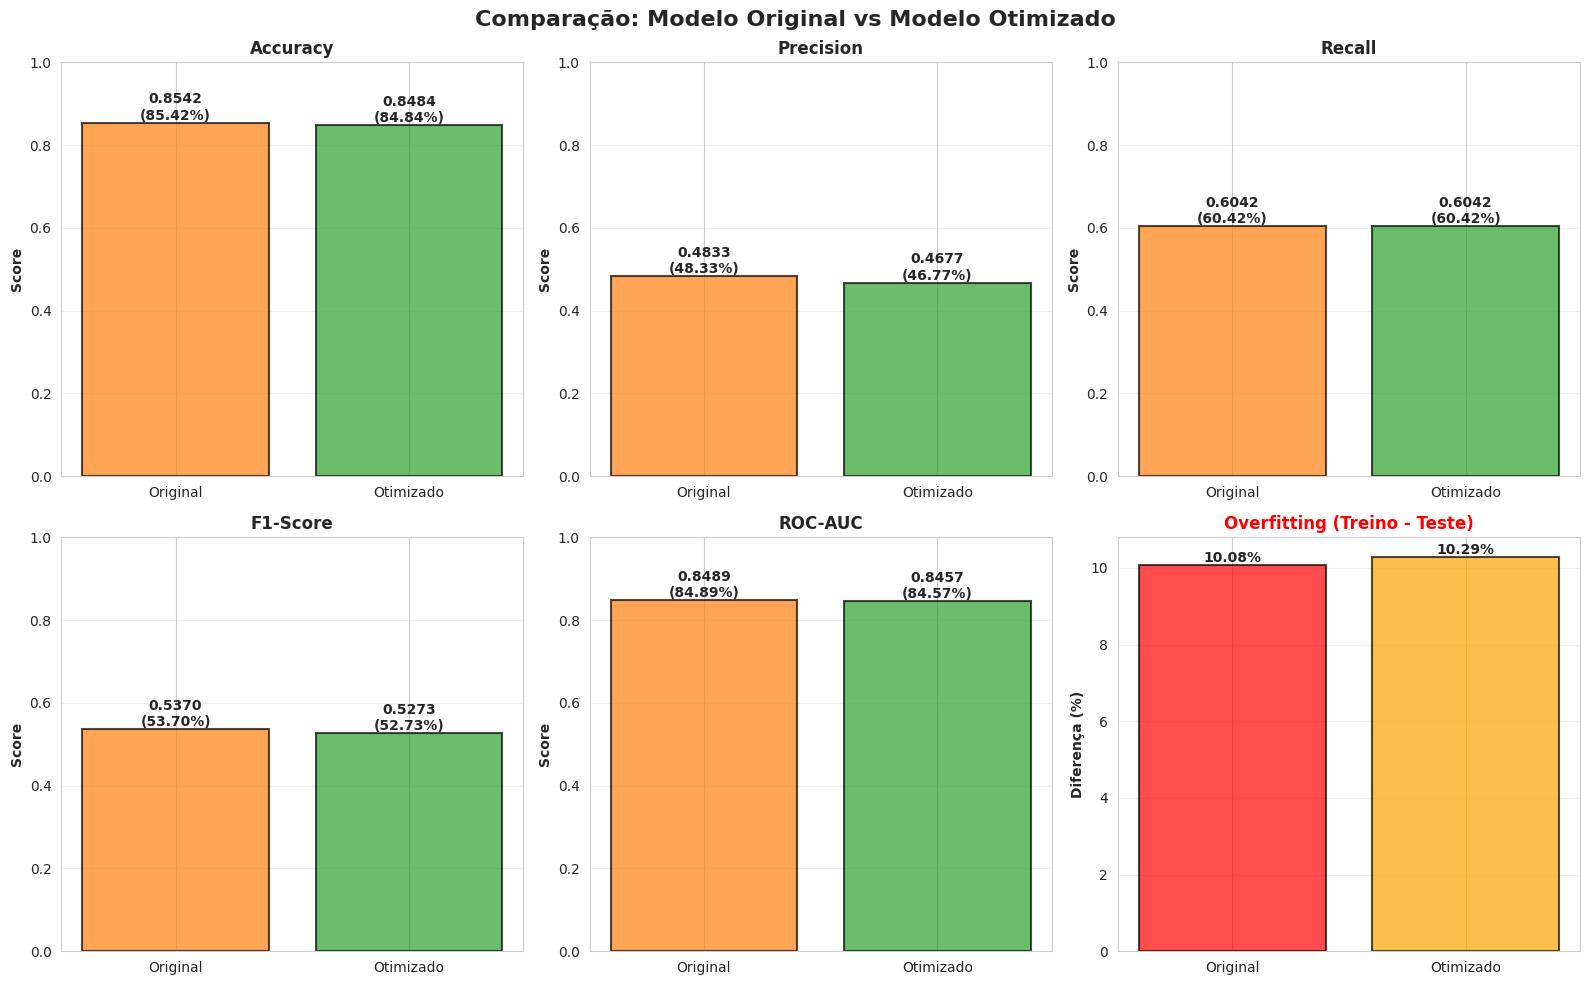


✅ Gráfico de Comparação salvo em: 08_original_vs_optimized.png

OTIMIZAÇÃO DE THRESHOLD DE DECISÃO

🎯 ANÁLISE DE THRESHOLDS:
   Threshold padrão: 0.50
   Melhor threshold (F1-Score): 0.5217
   F1-Score no melhor threshold: 0.5370

📊 MÉTRICAS COM THRESHOLD CUSTOMIZADO (0.5217):
   Accuracy:  0.8542 (85.42%)
   Precision: 0.4833 (48.33%)
   Recall:    0.6042 (60.42%)
   F1-Score:  0.5370 (53.70%)


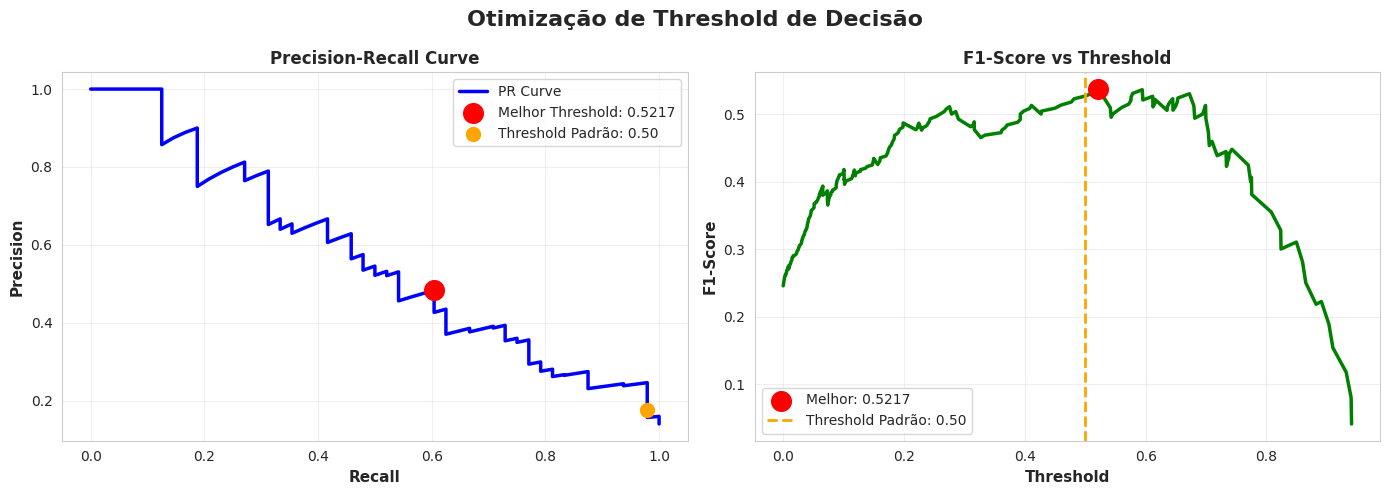


✅ Gráfico de Otimização de Threshold salvo em: 09_threshold_optimization.png

📋 SUMÁRIO FINAL - RECOMENDAÇÕES

    Métrica Original Otimizado Custom Thresh
   Accuracy   85.42%    84.84%        85.42%
  Precision   48.33%    46.77%        48.33%
     Recall   60.42%    60.42%        60.42%
   F1-Score   53.70%    52.73%        53.70%
    ROC-AUC   84.89%    84.57%           N/A
Overfitting   10.08%    10.29%           N/A


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')


# ==================== 15.1: HYPERPARAMETER TUNING - RANDOM FOREST ====================
print("\n" + "🔧"*40)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("🔧"*40)

# Definir grid de parâmetros reduzido (para evitar overfitting)
param_grid_rf = {
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [5, 8, 10],
    'max_features': ['sqrt', 'log2'],
    'n_estimators': [100, 150, 200]
}

print("\n📊 Grid de Parâmetros para Random Forest:")
print(f"  • max_depth: {param_grid_rf['max_depth']}")
print(f"  • min_samples_split: {param_grid_rf['min_samples_split']}")
print(f"  • min_samples_leaf: {param_grid_rf['min_samples_leaf']}")
print(f"  • max_features: {param_grid_rf['max_features']}")
print(f"  • n_estimators: {param_grid_rf['n_estimators']}")
print(f"  • Total de combinações: {np.prod([len(v) for v in param_grid_rf.values()])}")

# GridSearchCV com F1-Score como métrica principal
print("\n🔍 Executando GridSearchCV (isso pode levar alguns minutos)...")

scoring = make_scorer(f1_score, average='binary')

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring=scoring,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print(f"\n✅ GridSearchCV concluído!")
print(f"\n🏆 MELHORES PARÂMETROS:")
for param, value in grid_search_rf.best_params_.items():
    print(f"  • {param}: {value}")
print(f"\n📊 Melhor F1-Score (CV): {grid_search_rf.best_score_:.4f}")

# ==================== 15.2: COMPARAR MODELO OTIMIZADO VS ORIGINAL ====================
print("\n" + "="*80)
print("COMPARAÇÃO: MODELO OTIMIZADO vs MODELO ORIGINAL")
print("="*80)

# Modelo otimizado
rf_optimized = grid_search_rf.best_estimator_

# Predições no dataset de teste
y_test_pred_opt = rf_optimized.predict(X_test)
y_test_pred_proba_opt = rf_optimized.predict_proba(X_test)[:, 1]

# Predições no dataset de treino
y_train_pred_opt = rf_optimized.predict(X_train)

# Calcular métricas
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n🌳 RANDOM FOREST - ORIGINAL (Modelo Atual)")
print("-" * 80)

# Treino
acc_rf_train_orig = accuracy_score(y_train, y_train_pred_rf)
prec_rf_train_orig = precision_score(y_train, y_train_pred_rf)
rec_rf_train_orig = recall_score(y_train, y_train_pred_rf)
f1_rf_train_orig = f1_score(y_train, y_train_pred_rf)

# Teste
acc_rf_test_orig = accuracy_score(y_test, y_test_pred_rf)
prec_rf_test_orig = precision_score(y_test, y_test_pred_rf)
rec_rf_test_orig = recall_score(y_test, y_test_pred_rf)
f1_rf_test_orig = f1_score(y_test, y_test_pred_rf)
auc_rf_test_orig = roc_auc_score(y_test, y_test_pred_proba_rf)

print(f"\nTREINO:")
print(f"  Accuracy:  {acc_rf_train_orig:.4f} ({acc_rf_train_orig*100:.2f}%)")
print(f"  Precision: {prec_rf_train_orig:.4f} ({prec_rf_train_orig*100:.2f}%)")
print(f"  Recall:    {rec_rf_train_orig:.4f} ({rec_rf_train_orig*100:.2f}%)")
print(f"  F1-Score:  {f1_rf_train_orig:.4f} ({f1_rf_train_orig*100:.2f}%)")

print(f"\nTESTE:")
print(f"  Accuracy:  {acc_rf_test_orig:.4f} ({acc_rf_test_orig*100:.2f}%)")
print(f"  Precision: {prec_rf_test_orig:.4f} ({prec_rf_test_orig*100:.2f}%)")
print(f"  Recall:    {rec_rf_test_orig:.4f} ({rec_rf_test_orig*100:.2f}%)")
print(f"  F1-Score:  {f1_rf_test_orig:.4f} ({f1_rf_test_orig*100:.2f}%)")
print(f"  ROC-AUC:   {auc_rf_test_orig:.4f} ({auc_rf_test_orig*100:.2f}%)")

print(f"\n⚠️  OVERFITTING (Accuracy Delta): {(acc_rf_train_orig - acc_rf_test_orig)*100:.2f}%")
print(f"⚠️  OVERFITTING (F1-Score Delta): {(f1_rf_train_orig - f1_rf_test_orig)*100:.2f}%")

print("\n\n🌳 RANDOM FOREST - OTIMIZADO (Com GridSearchCV)")
print("-" * 80)

# Treino
acc_rf_train_opt = accuracy_score(y_train, y_train_pred_opt)
prec_rf_train_opt = precision_score(y_train, y_train_pred_opt)
rec_rf_train_opt = recall_score(y_train, y_train_pred_opt)
f1_rf_train_opt = f1_score(y_train, y_train_pred_opt)

# Teste
acc_rf_test_opt = accuracy_score(y_test, y_test_pred_opt)
prec_rf_test_opt = precision_score(y_test, y_test_pred_opt)
rec_rf_test_opt = recall_score(y_test, y_test_pred_opt)
f1_rf_test_opt = f1_score(y_test, y_test_pred_opt)
auc_rf_test_opt = roc_auc_score(y_test, y_test_pred_proba_opt)

print(f"\nTREINO:")
print(f"  Accuracy:  {acc_rf_train_opt:.4f} ({acc_rf_train_opt*100:.2f}%)")
print(f"  Precision: {prec_rf_train_opt:.4f} ({prec_rf_train_opt*100:.2f}%)")
print(f"  Recall:    {rec_rf_train_opt:.4f} ({rec_rf_train_opt*100:.2f}%)")
print(f"  F1-Score:  {f1_rf_train_opt:.4f} ({f1_rf_train_opt*100:.2f}%)")

print(f"\nTESTE:")
print(f"  Accuracy:  {acc_rf_test_opt:.4f} ({acc_rf_test_opt*100:.2f}%)")
print(f"  Precision: {prec_rf_test_opt:.4f} ({prec_rf_test_opt*100:.2f}%)")
print(f"  Recall:    {rec_rf_test_opt:.4f} ({rec_rf_test_opt*100:.2f}%)")
print(f"  F1-Score:  {f1_rf_test_opt:.4f} ({f1_rf_test_opt*100:.2f}%)")
print(f"  ROC-AUC:   {auc_rf_test_opt:.4f} ({auc_rf_test_opt*100:.2f}%)")

print(f"\n✅ OVERFITTING (Accuracy Delta): {(acc_rf_train_opt - acc_rf_test_opt)*100:.2f}%")
print(f"✅ OVERFITTING (F1-Score Delta): {(f1_rf_train_opt - f1_rf_test_opt)*100:.2f}%")

# Calcular melhorias
print("\n\n📈 COMPARAÇÃO DE MELHORIAS")
print("-" * 80)

mejoras = {
    'Accuracy': (acc_rf_test_opt - acc_rf_test_orig) * 100,
    'Precision': (prec_rf_test_opt - prec_rf_test_orig) * 100,
    'Recall': (rec_rf_test_opt - rec_rf_test_orig) * 100,
    'F1-Score': (f1_rf_test_opt - f1_rf_test_orig) * 100,
    'ROC-AUC': (auc_rf_test_opt - auc_rf_test_orig) * 100,
    'Overfitting': ((acc_rf_train_opt - acc_rf_test_opt) - (acc_rf_train_orig - acc_rf_test_orig)) * 100
}

for metrica, mejora in mejoras.items():
    sinal = "✅ +" if mejora >= 0 else "⚠️ "
    print(f"{metrica:15s}: {sinal}{mejora:6.2f}%")

# ==================== 15.3: FIGURA 8 - COMPARAÇÃO VISUAL ====================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparação: Modelo Original vs Modelo Otimizado', fontsize=16, fontweight='bold')

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
original = [acc_rf_test_orig, prec_rf_test_orig, rec_rf_test_orig, f1_rf_test_orig, auc_rf_test_orig]
otimizado = [acc_rf_test_opt, prec_rf_test_opt, rec_rf_test_opt, f1_rf_test_opt, auc_rf_test_opt]

for idx, (ax, metrica, orig, opt) in enumerate(zip(axes.flat[:5], metricas, original, otimizado)):
    x = ['Original', 'Otimizado']
    values = [orig, opt]
    colors = ['#ff7f0e', '#2ca02c']

    bars = ax.bar(x, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}\n({val*100:.2f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

    ax.set_ylim(0, 1)
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(f'{metrica}', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

# Subplot 6: Overfitting
ax = axes.flat[5]
x = ['Original', 'Otimizado']
overfitting = [
    (acc_rf_train_orig - acc_rf_test_orig) * 100,
    (acc_rf_train_opt - acc_rf_test_opt) * 100
]
colors = ['red', 'orange']

bars = ax.bar(x, overfitting, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, overfitting):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Diferença (%)', fontweight='bold')
ax.set_title('Overfitting (Treino - Teste)', fontweight='bold', fontsize=12, color='red')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('08_original_vs_optimized.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Gráfico de Comparação salvo em: 08_original_vs_optimized.png")

# ==================== 15.4: OTIMIZAÇÃO DE THRESHOLD ====================
print("\n" + "="*80)
print("OTIMIZAÇÃO DE THRESHOLD DE DECISÃO")
print("="*80)

from sklearn.metrics import precision_recall_curve

# Calcular Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_test_pred_proba_opt)

# Calcular F1-Score para cada threshold
f1_scores_threshold = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# Encontrar melhor threshold
best_threshold_idx = np.argmax(f1_scores_threshold)
best_threshold = thresholds[best_threshold_idx]

print(f"\n🎯 ANÁLISE DE THRESHOLDS:")
print(f"   Threshold padrão: 0.50")
print(f"   Melhor threshold (F1-Score): {best_threshold:.4f}")
print(f"   F1-Score no melhor threshold: {f1_scores_threshold[best_threshold_idx]:.4f}")

# Aplicar novo threshold
y_test_pred_custom = (y_test_pred_proba_opt >= best_threshold).astype(int)

acc_custom = accuracy_score(y_test, y_test_pred_custom)
prec_custom = precision_score(y_test, y_test_pred_custom)
rec_custom = recall_score(y_test, y_test_pred_custom)
f1_custom = f1_score(y_test, y_test_pred_custom)

print(f"\n📊 MÉTRICAS COM THRESHOLD CUSTOMIZADO ({best_threshold:.4f}):")
print(f"   Accuracy:  {acc_custom:.4f} ({acc_custom*100:.2f}%)")
print(f"   Precision: {prec_custom:.4f} ({prec_custom*100:.2f}%)")
print(f"   Recall:    {rec_custom:.4f} ({rec_custom*100:.2f}%)")
print(f"   F1-Score:  {f1_custom:.4f} ({f1_custom*100:.2f}%)")

# ==================== 15.5: FIGURA 9 - PRECISION-RECALL CURVE ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Otimização de Threshold de Decisão', fontsize=16, fontweight='bold')

# Precision-Recall Curve
axes[0].plot(recall, precision, color='blue', lw=2.5, label='PR Curve')
axes[0].scatter([recall[best_threshold_idx]], [precision[best_threshold_idx]],
                color='red', s=200, zorder=5, label=f'Melhor Threshold: {best_threshold:.4f}')
axes[0].scatter([recall[50]], [precision[50]], color='orange', s=100, zorder=4,
                label=f'Threshold Padrão: 0.50')
axes[0].set_xlabel('Recall', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Precision', fontweight='bold', fontsize=11)
axes[0].set_title('Precision-Recall Curve', fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)

# F1-Score vs Threshold
axes[1].plot(thresholds, f1_scores_threshold, color='green', lw=2.5)
axes[1].scatter([best_threshold], [f1_scores_threshold[best_threshold_idx]],
                color='red', s=200, zorder=5, label=f'Melhor: {best_threshold:.4f}')
axes[1].axvline(0.5, color='orange', linestyle='--', lw=2, label='Threshold Padrão: 0.50')
axes[1].set_xlabel('Threshold', fontweight='bold', fontsize=11)
axes[1].set_ylabel('F1-Score', fontweight='bold', fontsize=11)
axes[1].set_title('F1-Score vs Threshold', fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('09_threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Gráfico de Otimização de Threshold salvo em: 09_threshold_optimization.png")

# ==================== 15.6: SUMÁRIO FINAL ====================
print("\n" + "="*80)
print("📋 SUMÁRIO FINAL - RECOMENDAÇÕES")
print("="*80)

summary_data = {
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Overfitting'],
    'Original': [
        f"{acc_rf_test_orig*100:.2f}%",
        f"{prec_rf_test_orig*100:.2f}%",
        f"{rec_rf_test_orig*100:.2f}%",
        f"{f1_rf_test_orig*100:.2f}%",
        f"{auc_rf_test_orig*100:.2f}%",
        f"{(acc_rf_train_orig - acc_rf_test_orig)*100:.2f}%"
    ],
    'Otimizado': [
        f"{acc_rf_test_opt*100:.2f}%",
        f"{prec_rf_test_opt*100:.2f}%",
        f"{rec_rf_test_opt*100:.2f}%",
        f"{f1_rf_test_opt*100:.2f}%",
        f"{auc_rf_test_opt*100:.2f}%",
        f"{(acc_rf_train_opt - acc_rf_test_opt)*100:.2f}%"
    ],
    'Custom Thresh': [
        f"{acc_custom*100:.2f}%",
        f"{prec_custom*100:.2f}%",
        f"{rec_custom*100:.2f}%",
        f"{f1_custom*100:.2f}%",
        "N/A",
        "N/A"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

